# LGBM 성능 비교: `Modeling_LGBM_interpretation` vs 기본 LGBM

이 노트북의 목적은 **해석용 LGBM 설정**과 **기본 LGBM(default)** 을 같은 기준으로 비교하는 것이다.

중요한 점:
- 기존 `Modeling_LGBM_interpretation.ipynb`는 SHAP 해석 목적이라 **전체 데이터로 학습 후 in-sample 성능**을 확인하는 구조다.
- 기본 LGBM 성능과 공정하게 비교하려면 둘 다 **동일한 train/test split**으로 평가해야 한다.
- 따라서 여기서는 `final_features.json`의 `split_date`, `target`, `final_aic_features`를 그대로 사용한다.


## 0. 라이브러리 로드

`lightgbm`이 없으면 아래 주석을 해제해서 설치한 뒤 다시 실행하면 된다.


In [1]:
# 필요하면 주석 해제
# !pip install lightgbm

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_SEED = 42


## 1. 경로 설정

레포 어느 위치에서 실행해도 최대한 자동으로 `data`와 `outputs/baseline`을 찾게 해두었다.

보통 위치:
- 데이터: `../data/Finance_Final/dataset4_derived_full_with_dummies.csv`
- 설정: `../outputs/baseline/final_features.json`


In [2]:
def find_file(filename, preferred_subpaths=None):
    """
    현재 작업 폴더 기준으로 상위 폴더들을 훑으면서 파일을 찾는 함수.
    preferred_subpaths에 자주 쓰는 상대경로를 넣어두면 먼저 확인한다.
    """
    cwd = Path.cwd().resolve()
    candidates = []
    preferred_subpaths = preferred_subpaths or []

    for base in [cwd, *cwd.parents]:
        for sub in preferred_subpaths:
            candidates.append(base / sub / filename)
        candidates.append(base / filename)

    # 중복 제거
    seen = set()
    unique_candidates = []
    for p in candidates:
        if p not in seen:
            unique_candidates.append(p)
            seen.add(p)

    for p in unique_candidates:
        if p.exists():
            return p

    # 그래도 못 찾으면 상위 폴더에서 재귀 검색
    for base in [cwd, *cwd.parents]:
        try:
            matches = [p for p in base.rglob(filename) if ".git" not in p.parts]
            if matches:
                return matches[0]
        except PermissionError:
            pass

    raise FileNotFoundError(f"{filename} 파일을 찾지 못했습니다. 현재 위치: {cwd}")


CFG_PATH = find_file(
    "final_features.json",
    preferred_subpaths=[
        Path("outputs") / "baseline",
        Path("..") / "outputs" / "baseline",
    ],
)

with open(CFG_PATH, encoding="utf-8") as f:
    cfg = json.load(f)

DATA_FILE_NAME = cfg.get("data_file", "dataset4_derived_full_with_dummies.csv")

DATA_PATH = find_file(
    DATA_FILE_NAME,
    preferred_subpaths=[
        Path("data") / "Finance_Final",
        Path("..") / "data" / "Finance_Final",
    ],
)

OUT_DIR = CFG_PATH.parent
COMPARE_DIR = OUT_DIR / "lgbm_interpretation_vs_default"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

print("CFG_PATH :", CFG_PATH)
print("DATA_PATH:", DATA_PATH)
print("OUT_DIR  :", COMPARE_DIR)


CFG_PATH : /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/final_features.json
DATA_PATH: /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../data/Finance_Final/dataset4_derived_full_with_dummies.csv
OUT_DIR  : /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default


## 2. 설정값 확인

`final_features.json`에서 target, split_date, feature list를 그대로 가져온다.


In [3]:
TARGET = cfg["target"]
SPLIT_DATE = pd.Timestamp(cfg["split_date"])
TEST_SIZE = cfg.get("test_size")
FEATURES = list(cfg["final_aic_features"])

print("TARGET    :", TARGET)
print("SPLIT_DATE:", SPLIT_DATE.date())
print("TEST_SIZE :", TEST_SIZE)
print("n_features:", len(FEATURES))
print("FEATURES  :", FEATURES)


TARGET    : oil_diff_target
SPLIT_DATE: 2022-07-20
TEST_SIZE : 0.2
n_features: 19
FEATURES  : ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'TreasuryYield', 'oil_diff_lag1', 'MA_ratio', 'MA_5_gt_MA_20', 'vix_high', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_opec_cut']


## 3. 데이터 로드 및 train/test 분리

날짜 컬럼은 `date`, `Date`, `DATE` 중 하나를 우선 사용하고, 없으면 첫 번째 컬럼을 날짜로 가정한다.


In [4]:
cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
DATE_COL = next((c for c in ["date", "Date", "DATE"] if c in cols), cols[0])

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.rename(columns={DATE_COL: "date"}).set_index("date").sort_index()

needed_cols = FEATURES + [TARGET]
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"데이터에 없는 컬럼: {missing_cols}")

df_model = df[needed_cols].dropna().copy()

df_train = df_model.loc[df_model.index < SPLIT_DATE].copy()
df_test = df_model.loc[df_model.index >= SPLIT_DATE].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]

X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print("전체 데이터:", df.shape)
print("모델 데이터:", df_model.shape)
print("train:", df_train.index.min().date(), "~", df_train.index.max().date(), "| n =", len(df_train))
print("test :", df_test.index.min().date(), "~", df_test.index.max().date(), "| n =", len(df_test))
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


전체 데이터: (4548, 43)
모델 데이터: (4547, 20)
train: 2008-01-31 ~ 2022-07-19 | n = 3637
test : 2022-07-20 ~ 2026-03-13 | n = 910
X_train: (3637, 19) | X_test: (910, 19)


## 4. 평가 함수

회귀 성능은 `RMSE`, `MAE`, `R2`, `Directional_Accuracy`로 비교한다.

- `RMSE`, `MAE`: 작을수록 좋음
- `R2`: 클수록 좋음
- `Directional_Accuracy`: 실제 변화 방향과 예측 변화 방향이 맞은 비율


In [5]:
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # 예측값이 정확히 0이면 방향 판단이 애매하므로 제외
    mask = y_pred != 0
    if mask.sum() == 0:
        return np.nan

    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Directional_Accuracy": directional_accuracy(y_true, y_pred),
    }


def make_result_row(model_name, model_desc, y_true, y_pred, n_features):
    return {
        "model": model_name,
        "description": model_desc,
        "n_features": n_features,
        **regression_metrics(y_true, y_pred),
    }


## 5. 기준선: naive zero

유가 변화량 예측에서는 `항상 0으로 예측`하는 모델도 기준선으로 같이 보는 게 좋다.


In [6]:
pred_naive_zero = np.zeros(len(y_test))

naive_zero_row = make_result_row(
    model_name="naive_zero",
    model_desc="항상 0으로 예측",
    y_true=y_test,
    y_pred=pred_naive_zero,
    n_features=0,
)

naive_zero_row


{'model': 'naive_zero',
 'description': '항상 0으로 예측',
 'n_features': 0,
 'RMSE': 1.7002833635848813,
 'MAE': 1.2582637362637366,
 'R2': -5.109837033034914e-05,
 'Directional_Accuracy': nan}

## 6. 모델 1: 기본 LGBM(default)

`Modeling_LGBM_prediction.ipynb`의 기본 LGBM과 같은 취지로, 튜닝 없이 `LGBMRegressor(random_state=42)`만 사용한다.


In [7]:
lgbm_default = LGBMRegressor(
    random_state=RANDOM_SEED,
    verbosity=-1,
)

lgbm_default.fit(X_train, y_train)
pred_default = lgbm_default.predict(X_test)

default_row = make_result_row(
    model_name="LGBM_default",
    model_desc="기본 LGBM, 튜닝 없음",
    y_true=y_test,
    y_pred=pred_default,
    n_features=len(FEATURES),
)

default_row


{'model': 'LGBM_default',
 'description': '기본 LGBM, 튜닝 없음',
 'n_features': 19,
 'RMSE': 1.8582204741358712,
 'MAE': 1.3503462964515904,
 'R2': -0.19446674184219015,
 'Directional_Accuracy': 0.5274725274725275}

## 7. 모델 2: `Modeling_LGBM_interpretation` 방식 LGBM

기존 해석용 노트북에서 사용한 설정을 **동일한 train/test 기준**으로 평가한다.

해석용 설정:
- `n_estimators=300`
- `learning_rate=0.05`
- `num_leaves=31`
- `random_state=42`


In [8]:
interpretation_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": RANDOM_SEED,
    "verbosity": -1,
}

lgbm_interpretation_style = LGBMRegressor(**interpretation_params)
lgbm_interpretation_style.fit(X_train, y_train)
pred_interpretation_style = lgbm_interpretation_style.predict(X_test)

interpretation_style_row = make_result_row(
    model_name="LGBM_interpretation_style",
    model_desc="Modeling_LGBM_interpretation의 파라미터를 train/test로 재평가",
    y_true=y_test,
    y_pred=pred_interpretation_style,
    n_features=len(FEATURES),
)

interpretation_style_row


{'model': 'LGBM_interpretation_style',
 'description': 'Modeling_LGBM_interpretation의 파라미터를 train/test로 재평가',
 'n_features': 19,
 'RMSE': 1.8668620404137612,
 'MAE': 1.3551567586911715,
 'R2': -0.2056021962126977,
 'Directional_Accuracy': 0.512087912087912}

## 8. 참고: 해석용 노트북의 원래 방식(in-sample)

아래 결과는 **전체 데이터로 학습하고 전체 데이터에서 평가**한 값이다.

따라서 test 성능 비교용으로 쓰면 안 되고, 기존 `Modeling_LGBM_interpretation.ipynb`에서 찍히던 `in-sample R2/RMSE`를 확인하는 참고용이다.


In [9]:
lgbm_interpretation_insample = LGBMRegressor(**interpretation_params)

X_all = df_model[FEATURES]
y_all = df_model[TARGET]

lgbm_interpretation_insample.fit(X_all, y_all)
pred_interpretation_insample = lgbm_interpretation_insample.predict(X_all)

interpretation_insample_row = make_result_row(
    model_name="LGBM_interpretation_in_sample",
    model_desc="전체 데이터 학습 + 전체 데이터 평가, 성능 비교용 아님",
    y_true=y_all,
    y_pred=pred_interpretation_insample,
    n_features=len(FEATURES),
)

interpretation_insample_row


{'model': 'LGBM_interpretation_in_sample',
 'description': '전체 데이터 학습 + 전체 데이터 평가, 성능 비교용 아님',
 'n_features': 19,
 'RMSE': 1.399314165675527,
 'MAE': 0.8452985908567919,
 'R2': 0.530481504659039,
 'Directional_Accuracy': 0.7824939520563009}

## 9. 성능 비교 표

핵심 비교 대상은 아래 두 개다.

1. `LGBM_default`
2. `LGBM_interpretation_style`

`LGBM_interpretation_in_sample`은 참고용으로만 본다.


In [10]:
compare = pd.DataFrame([
    naive_zero_row,
    default_row,
    interpretation_style_row,
    interpretation_insample_row,
])

# RMSE 기준 정렬
compare_sorted = compare.sort_values("RMSE").reset_index(drop=True)

display(compare_sorted.round(5))


,model,description,n_features,RMSE,MAE,R2,Directional_Accuracy
0,LGBM_interpretation_in_sample,"전체 데이터 학습 + 전체 데이터 평가, 성능 비교용 아님",19,1.39931,0.84530,0.53048,0.78249
1,naive_zero,항상 0으로 예측,0,1.70028,1.25826,-0.00005,NaN
2,LGBM_default,"기본 LGBM, 튜닝 없음",19,1.85822,1.35035,-0.19447,0.52747
3,LGBM_interpretation_style,Modeling_LGBM_interpretation의 파라미터를 train/test...,19,1.86686,1.35516,-0.20560,0.51209


In [11]:
# default 대비 개선율 계산
default_rmse = default_row["RMSE"]
default_mae = default_row["MAE"]
default_r2 = default_row["R2"]
default_dir = default_row["Directional_Accuracy"]

fair_compare = compare[compare["model"].isin(["LGBM_default", "LGBM_interpretation_style"])].copy()

fair_compare["RMSE_improve_vs_default"] = (default_rmse - fair_compare["RMSE"]) / default_rmse
fair_compare["MAE_improve_vs_default"] = (default_mae - fair_compare["MAE"]) / default_mae
fair_compare["R2_gap_vs_default"] = fair_compare["R2"] - default_r2
fair_compare["DirAcc_gap_vs_default"] = fair_compare["Directional_Accuracy"] - default_dir

display(fair_compare.round(5))


,model,description,n_features,RMSE,MAE,R2,Directional_Accuracy,RMSE_improve_vs_default,MAE_improve_vs_default,R2_gap_vs_default,DirAcc_gap_vs_default
1,LGBM_default,"기본 LGBM, 튜닝 없음",19,1.85822,1.35035,-0.19447,0.52747,0.00000,0.00000,0.00000,0.00000
2,LGBM_interpretation_style,Modeling_LGBM_interpretation의 파라미터를 train/test...,19,1.86686,1.35516,-0.20560,0.51209,-0.00465,-0.00356,-0.01114,-0.01538


## 10. 시각화 1: 성능 지표 비교

비교용 모델만 따로 뽑아서 RMSE, MAE, R2, 방향 정확도를 시각화한다.


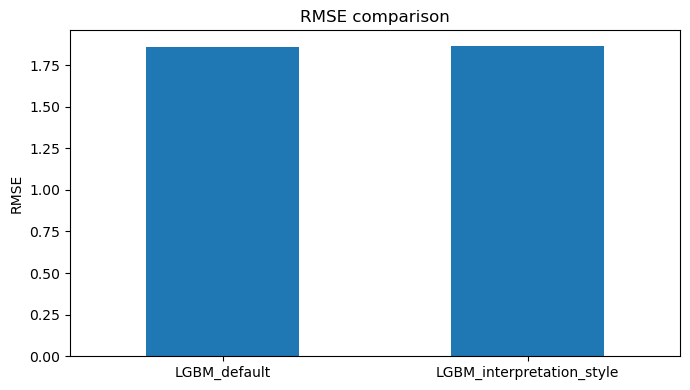

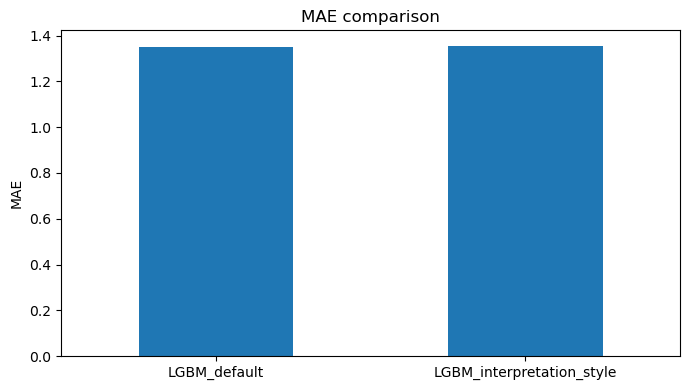

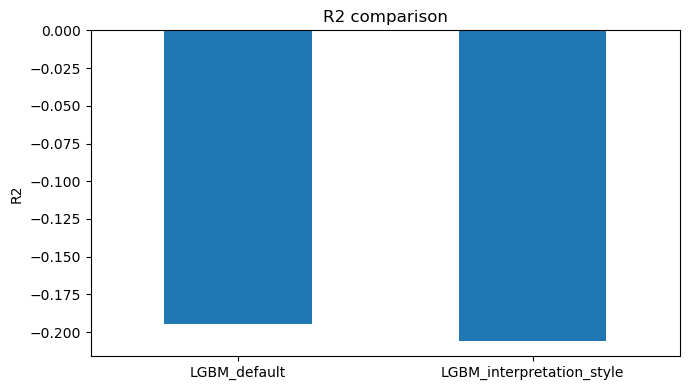

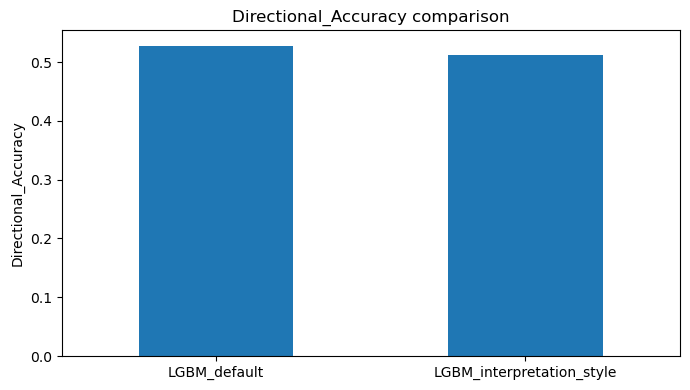

In [12]:
plot_df = fair_compare.set_index("model")[["RMSE", "MAE", "R2", "Directional_Accuracy"]]

for metric in plot_df.columns:
    ax = plot_df[metric].plot(kind="bar", figsize=(7, 4), rot=0)
    ax.set_title(f"{metric} comparison")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()


## 11. 시각화 2: 실제값 vs 예측값

테스트 구간에서 실제 변화량과 두 LGBM 예측값을 비교한다.


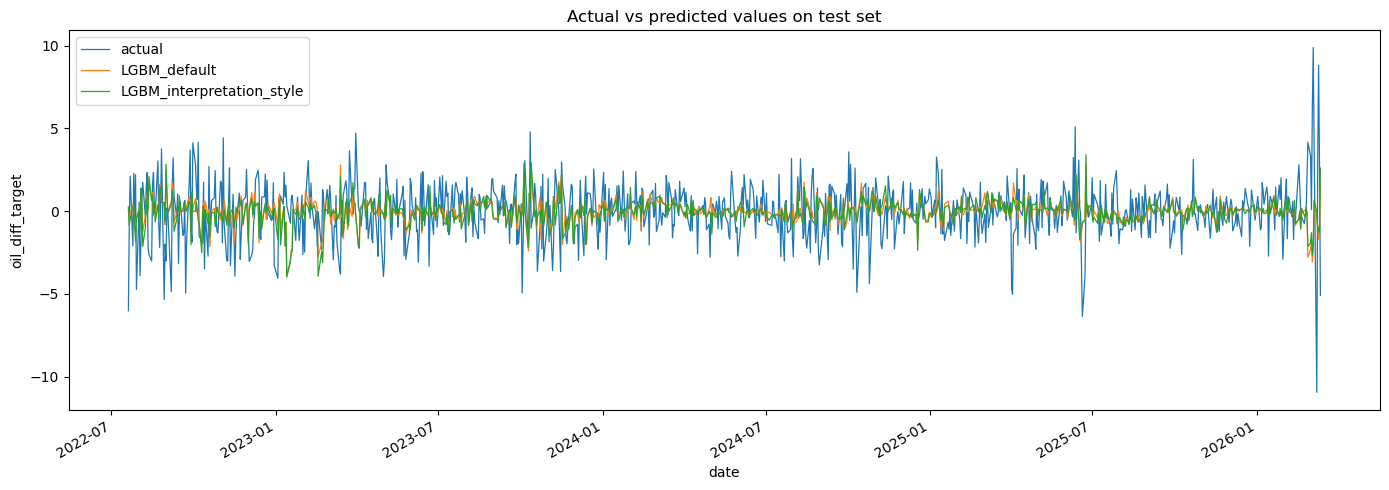

,actual,LGBM_default,LGBM_interpretation_style
date,,,
2022-07-20,-6.01,0.087645,0.257852
2022-07-21,-0.73,-0.660415,-0.837854
2022-07-22,2.12,-0.121505,-0.479330
2022-07-25,-2.09,0.414401,0.258551
2022-07-26,2.29,0.272884,0.281313


In [13]:
pred_test_df = pd.DataFrame({
    "actual": y_test.values,
    "LGBM_default": pred_default,
    "LGBM_interpretation_style": pred_interpretation_style,
}, index=y_test.index)

ax = pred_test_df.plot(figsize=(14, 5), linewidth=0.9)
ax.set_title("Actual vs predicted values on test set")
ax.set_xlabel("date")
ax.set_ylabel(TARGET)
plt.tight_layout()
plt.show()

display(pred_test_df.head())


## 12. 시각화 3: 잔차 비교

잔차는 `actual - predicted`로 계산한다.

- 잔차가 0 주변에 몰릴수록 좋음
- 특정 기간에 잔차가 크게 튀면 그 시기의 이벤트/시장 국면을 따로 봐야 함


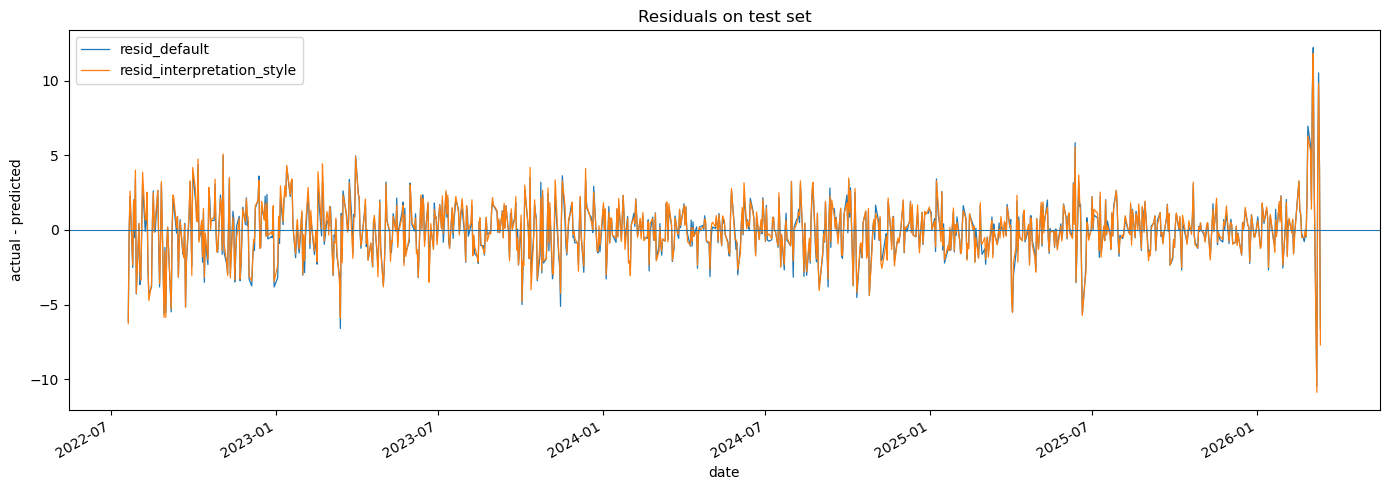

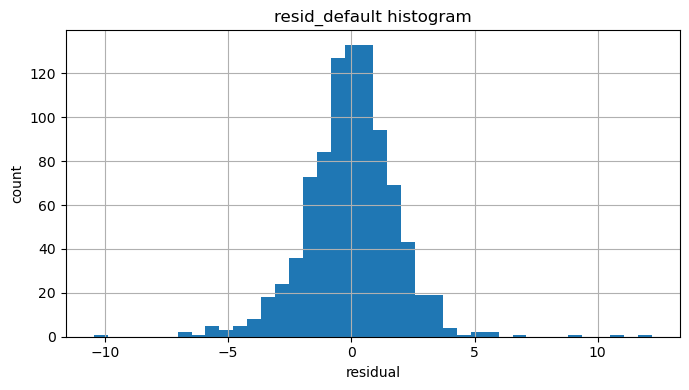

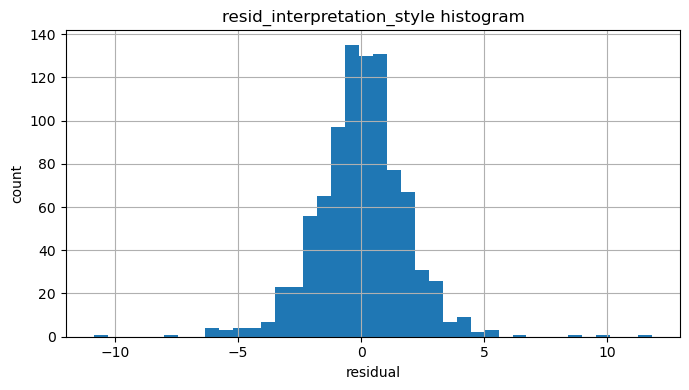

,count,mean,std,min,25%,50%,75%,max
resid_default,910.0,-0.00998,1.85922,-10.45309,-0.98637,0.01140,1.06012,12.20702
resid_interpretation_style,910.0,0.02860,1.86767,-10.86341,-0.94837,0.02111,1.02445,11.81616


In [14]:
resid_df = pd.DataFrame({
    "resid_default": y_test.values - pred_default,
    "resid_interpretation_style": y_test.values - pred_interpretation_style,
}, index=y_test.index)

ax = resid_df.plot(figsize=(14, 5), linewidth=0.9)
ax.axhline(0, linewidth=0.8)
ax.set_title("Residuals on test set")
ax.set_xlabel("date")
ax.set_ylabel("actual - predicted")
plt.tight_layout()
plt.show()

for col in resid_df.columns:
    ax = resid_df[col].hist(bins=40, figsize=(7, 4))
    ax.set_title(f"{col} histogram")
    ax.set_xlabel("residual")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

display(resid_df.describe().T.round(5))


## 13. 변수 중요도 비교

두 모델의 `feature_importances_`를 비교한다.

주의:
- LightGBM의 기본 feature importance는 split 기반 중요도라 SHAP 중요도와 해석이 다르다.
- 성능 비교의 핵심은 9~12번이고, 이 부분은 참고용이다.


,feature,importance_default,importance_interpretation_style,gap_interpretation_minus_default
0,OilPrice,513,1480,967
1,MA_ratio,420,1219,799
2,oil_diff_lag1,385,1159,774
3,OilInventories,333,1063,730
4,VIX,286,959,673
5,TreasuryYield,315,941,626
6,IndustryProduction,174,541,367
7,CPE,158,481,323
8,OPECProduction,168,480,312
9,RealInterestRate,163,451,288


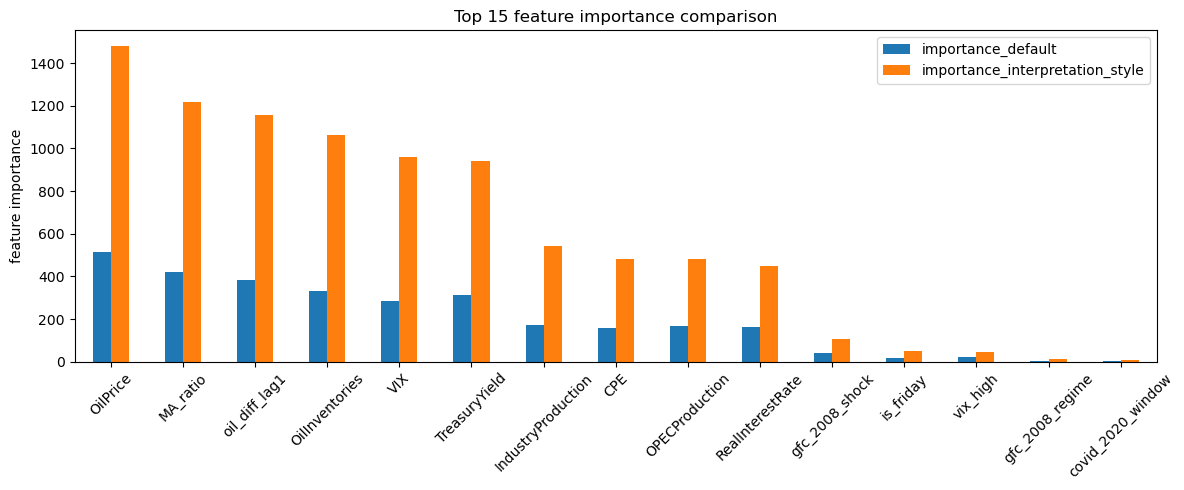

In [15]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_default": lgbm_default.feature_importances_,
    "importance_interpretation_style": lgbm_interpretation_style.feature_importances_,
})

importance_df["gap_interpretation_minus_default"] = (
    importance_df["importance_interpretation_style"] - importance_df["importance_default"]
)

importance_df = importance_df.sort_values(
    "importance_interpretation_style",
    ascending=False
).reset_index(drop=True)

display(importance_df)

top_n = min(15, len(importance_df))
importance_plot = importance_df.head(top_n).set_index("feature")[[
    "importance_default",
    "importance_interpretation_style",
]]

ax = importance_plot.plot(kind="bar", figsize=(12, 5), rot=45)
ax.set_title(f"Top {top_n} feature importance comparison")
ax.set_xlabel("")
ax.set_ylabel("feature importance")
plt.tight_layout()
plt.show()


## 14. 결과 저장

아래 파일이 저장된다.

- `lgbm_interpretation_vs_default_compare.csv`
- `lgbm_interpretation_vs_default_fair_compare.csv`
- `lgbm_interpretation_vs_default_predictions.csv`
- `lgbm_interpretation_vs_default_residuals.csv`
- `lgbm_interpretation_vs_default_feature_importance.csv`


In [16]:
compare_sorted.to_csv(COMPARE_DIR / "lgbm_interpretation_vs_default_compare.csv", index=False)
fair_compare.to_csv(COMPARE_DIR / "lgbm_interpretation_vs_default_fair_compare.csv", index=False)
pred_test_df.to_csv(COMPARE_DIR / "lgbm_interpretation_vs_default_predictions.csv", index=True)
resid_df.to_csv(COMPARE_DIR / "lgbm_interpretation_vs_default_residuals.csv", index=True)
importance_df.to_csv(COMPARE_DIR / "lgbm_interpretation_vs_default_feature_importance.csv", index=False)

print("저장 완료:")
for fname in [
    "lgbm_interpretation_vs_default_compare.csv",
    "lgbm_interpretation_vs_default_fair_compare.csv",
    "lgbm_interpretation_vs_default_predictions.csv",
    "lgbm_interpretation_vs_default_residuals.csv",
    "lgbm_interpretation_vs_default_feature_importance.csv",
]:
    print("-", COMPARE_DIR / fname)


저장 완료:
- /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default/lgbm_interpretation_vs_default_compare.csv
- /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default/lgbm_interpretation_vs_default_fair_compare.csv
- /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default/lgbm_interpretation_vs_default_predictions.csv
- /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default/lgbm_interpretation_vs_default_residuals.csv
- /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/src/../outputs/baseline/lgbm_interpretation_vs_default/lgbm_interpretation_vs_default_feature_importance.csv


## 15. 결론 자동 출력

아래 셀은 두 모델 중 어떤 모델이 test RMSE 기준으로 더 나은지 자동으로 문장화한다.


In [17]:
rmse_default = default_row["RMSE"]
rmse_interp = interpretation_style_row["RMSE"]

mae_default = default_row["MAE"]
mae_interp = interpretation_style_row["MAE"]

r2_default = default_row["R2"]
r2_interp = interpretation_style_row["R2"]

dir_default = default_row["Directional_Accuracy"]
dir_interp = interpretation_style_row["Directional_Accuracy"]

if rmse_interp < rmse_default:
    winner = "LGBM_interpretation_style"
    rmse_msg = f"해석용 LGBM 설정이 기본 LGBM보다 RMSE가 낮다. 개선율: {(rmse_default - rmse_interp) / rmse_default:.2%}"
elif rmse_interp > rmse_default:
    winner = "LGBM_default"
    rmse_msg = f"기본 LGBM이 해석용 LGBM 설정보다 RMSE가 낮다. 기본 모델 대비 해석용 모델 RMSE 악화율: {(rmse_interp - rmse_default) / rmse_default:.2%}"
else:
    winner = "동률"
    rmse_msg = "두 모델의 RMSE가 같다."

print("===== 결론 =====")
print("RMSE 기준 우세 모델:", winner)
print(rmse_msg)
print()
print(f"LGBM_default              | RMSE={rmse_default:.5f}, MAE={mae_default:.5f}, R2={r2_default:.5f}, DirAcc={dir_default:.5f}")
print(f"LGBM_interpretation_style | RMSE={rmse_interp:.5f}, MAE={mae_interp:.5f}, R2={r2_interp:.5f}, DirAcc={dir_interp:.5f}")
print()
print("주의: LGBM_interpretation_in_sample은 전체 데이터로 학습·평가한 참고값이라 test 성능 비교 결론에 포함하지 않는다.")


===== 결론 =====
RMSE 기준 우세 모델: LGBM_default
기본 LGBM이 해석용 LGBM 설정보다 RMSE가 낮다. 기본 모델 대비 해석용 모델 RMSE 악화율: 0.47%

LGBM_default              | RMSE=1.85822, MAE=1.35035, R2=-0.19447, DirAcc=0.52747
LGBM_interpretation_style | RMSE=1.86686, MAE=1.35516, R2=-0.20560, DirAcc=0.51209

주의: LGBM_interpretation_in_sample은 전체 데이터로 학습·평가한 참고값이라 test 성능 비교 결론에 포함하지 않는다.
